# Stage 2 -- Full-block PCA phase coordinates, all movement types

Runs `fit_pca_phase_coordinates` on every disjoint positive-movement run found
for subject 002 (58 runs across 6 day/part/skill conditions -- see
`PROGRESS.md` Stage 1 for why it's 58 runs, not 6 continuous blocks), for
both hands, on the **full, untruncated** run length. Caches every fit's
`(samples, cycles)` for later stages. Highlights the longest run per
condition ("primary" block) with phase/radius/perp/theta plots and a
reconstruction-error check.


In [1]:
import sys, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import _loading as L
import _plotting as P
from phase_coordinates import fit_pca_phase_coordinates, reconstruct_phase_coordinates

FS_HZ = 60.0
F_RANGE = (0.5, 3.0)  # validated empirically below for all 3 skills, see probe cell
HANDS = ["r_hand", "l_hand"]

CACHE_DIR = NB_DIR / "cache"
CACHE_DIR.mkdir(exist_ok=True)
CACHE_PATH = CACHE_DIR / "pca_results.pkl"

runs = L.list_available_blocks("002")
print(f"{len(runs)} disjoint runs across conditions:")
display(runs.groupby(["day", "part", "skill"]).size().rename("n_runs"))


Detected hostname: fedora-donchin-office
Using root directory: /home/opher/Repositories/phase-coordinates/test_data
Detected hostname: fedora-donchin-office
Using root directory: /home/opher/Repositories/phase-coordinates/test_data
58 disjoint runs across conditions:


day  part  skill
1    s     climb    11
           jump     13
           walk     11
3    e     climb     6
           jump      7
           walk     10
Name: n_runs, dtype: int64

## f_range sanity check

A single Hilbert bandpass range `(0.5, 3.0)` Hz was probed against the
longest run of each (skill, day, part) condition before committing to it for
all 58 runs x 2 hands. Median per-cycle duration should land inside Noam's
own skill-specific duration windows (walk 0.5-3.1s, jump 0.4-1.5s, climb
0.4-1.7s) as a sanity check that the band isn't badly mismatched to the
task's real cadence.

In [2]:
def _hand_xyz_relative_to_root(seg, hand):
    cols = [f"{hand}.x", f"{hand}.y", f"{hand}.z"]
    root_cols = ["root.x", "root.y", "root.z"]
    X = seg[cols].to_numpy(dtype=float) - seg[root_cols].to_numpy(dtype=float)
    return X, cols


probe_rows = []
for (day, part, skill), group in runs.groupby(["day", "part", "skill"]):
    row = group.loc[group["run_duration_sec"].idxmax()]
    pos = L.load_position_file(row["path"])
    seg = pos.iloc[int(row.run_start):int(row.run_end)]
    X, _ = _hand_xyz_relative_to_root(seg, "r_hand")
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        _, cycles, _ = fit_pca_phase_coordinates(X, ref_signal=X[:, 1], sampling_rate_hz=FS_HZ, f_range=F_RANGE)
        nwarn = len(w)
    med = float(cycles["duration"].median()) if len(cycles) else float("nan")
    probe_rows.append({"skill": skill, "day": day, "part": part, "run_duration_sec": row.run_duration_sec,
                        "n_cycles": len(cycles), "median_cycle_duration_s": med, "warnings": nwarn})

probe_df = pd.DataFrame(probe_rows)
display(probe_df)
print("All median cycle durations fall inside the expected skill-specific ranges "
      "(walk 0.5-3.1s, jump 0.4-1.5s, climb 0.4-1.7s); zero warnings. "
      "Using F_RANGE=(0.5, 3.0) uniformly for all 58 runs x 2 hands below.")


,skill,day,part,run_duration_sec,n_cycles,median_cycle_duration_s,warnings
0,climb,1,s,22.983333,20,1.066667,0
1,jump,1,s,8.983333,10,0.925000,0
2,walk,1,s,25.983333,26,1.033333,0
3,climb,3,e,28.983333,39,0.750000,0
4,jump,3,e,30.983333,41,0.750000,0
5,walk,3,e,14.983333,23,0.666667,0


All median cycle durations fall inside the expected skill-specific ranges (walk 0.5-3.1s, jump 0.4-1.5s, climb 0.4-1.7s); zero warnings. Using F_RANGE=(0.5, 3.0) uniformly for all 58 runs x 2 hands below.


## Fit every run x hand (116 fits)

Loads each run's position file once (cached across the multiple runs that
share a source file), computes hand-xyz-relative-to-root for each hand, and
fits `fit_pca_phase_coordinates` on the full run. Failures/anomalies are
collected into a summary table rather than raising -- a run that's too short
or produces zero cycles is data, not a bug.

In [3]:
file_cache = {}
results = {}   # key: (subject, day, part, skill, source_file, movement_run_id, hand) -> dict(samples, cycles, meta)
summary_rows = []

for _, row in runs.iterrows():
    pos = L.load_position_file(row["path"], file_cache)
    seg = pos.iloc[int(row.run_start):int(row.run_end)]
    for hand in HANDS:
        key = (row.subject, int(row.day), row.part, row.skill, row.source_file, int(row.movement_run_id), hand)
        rec = {"subject": row.subject, "day": int(row.day), "part": row.part, "skill": row.skill,
               "source_file": row.source_file, "movement_run_id": int(row.movement_run_id), "hand": hand,
               "run_duration_sec": row.run_duration_sec}
        try:
            X, cols = _hand_xyz_relative_to_root(seg, hand)
            with warnings.catch_warnings(record=True) as w:
                warnings.simplefilter("always")
                samples, cycles, details = fit_pca_phase_coordinates(
                    X, ref_signal=X[:, 1], sampling_rate_hz=FS_HZ, f_range=F_RANGE,
                )
                nwarn = len(w)
            X_hat = reconstruct_phase_coordinates(samples, cycles)
            fitted = ~np.isnan(X_hat[:, 0])
            recon_err = float(np.linalg.norm(X_hat[fitted] - X[fitted], axis=1).max()) if fitted.any() else float("nan")
            results[key] = {"samples": samples, "cycles": cycles, "meta": rec}
            rec.update(n_cycles=len(cycles), n_fitted_samples=int(fitted.sum()), n_total_samples=len(X),
                       reconstruction_error_max=recon_err, warnings=nwarn, error="")
        except Exception as exc:
            rec.update(n_cycles=0, n_fitted_samples=0, n_total_samples=len(seg),
                       reconstruction_error_max=float("nan"), warnings=0, error=str(exc))
        summary_rows.append(rec)

summary_df = pd.DataFrame(summary_rows)
print(f"{len(summary_df)} run x hand fits attempted ({summary_df['error'].eq('').sum()} succeeded, "
      f"{(~summary_df['error'].eq('')).sum()} raised an exception).")


116 run x hand fits attempted (116 succeeded, 0 raised an exception).


In [4]:
with open(CACHE_PATH, "wb") as fh:
    pickle.dump(results, fh)
print(f"Cached {len(results)} (samples, cycles) pairs to {CACHE_PATH}")
print("Cache key = (subject, day, part, skill, source_file, movement_run_id, hand) -> "
      "{'samples': DataFrame, 'cycles': DataFrame, 'meta': dict}")

anomalies = summary_df[(summary_df.n_cycles == 0) | (~summary_df.error.eq(""))]
print(f"\n{len(anomalies)} anomalous run x hand fits (zero cycles or exception):")
display(anomalies if len(anomalies) else "none")

display(summary_df.groupby(["skill"])[["n_cycles", "reconstruction_error_max"]].describe())


Cached 116 (samples, cycles) pairs to /home/opher/Repositories/phase-coordinates/notebooks/gorilla_tag_analysis/cache/pca_results.pkl
Cache key = (subject, day, part, skill, source_file, movement_run_id, hand) -> {'samples': DataFrame, 'cycles': DataFrame, 'meta': dict}

0 anomalous run x hand fits (zero cycles or exception):


'none'

n_cycles                                                      \
         count       mean        std  min   25%   50%    75%   max   
skill                                                                
climb     34.0  18.764706  12.567536  3.0  6.00  17.0  30.00  39.0   
jump      40.0  15.275000  10.834389  6.0  7.00   9.0  24.25  41.0   
walk      42.0  14.952381   5.983524  4.0  9.25  16.0  19.00  26.0   

      reconstruction_error_max                                            \
                         count          mean           std           min   
skill                                                                      
climb                     34.0  4.044705e-14  9.571654e-15  2.586415e-14   
jump                      40.0  3.589557e-14  9.145260e-15  2.289106e-14   
walk                      42.0  3.295149e-14  1.340190e-14  1.630479e-14   

                                                               
                25%           50%           75%           max  
skill                                                          
climb  3.351623e-14  3.924101e-14  4.484765e-14  7.149698e-14  
jump   2.920157e-14  3.366446e-14  4.372886e-14  5.281489e-14  
walk   2.063104e-14  3.219360e-14  4.292066e-14  6.862005e-14

## Primary blocks (longest run per condition): phase/radius/perp/theta over the full run

The 6 "primary" blocks -- the longest run for each of the 6 (day, part,
skill) conditions -- shown end-to-end (not a 20s excerpt) for the right hand,
plus a reconstruction-error overlay sanity check.

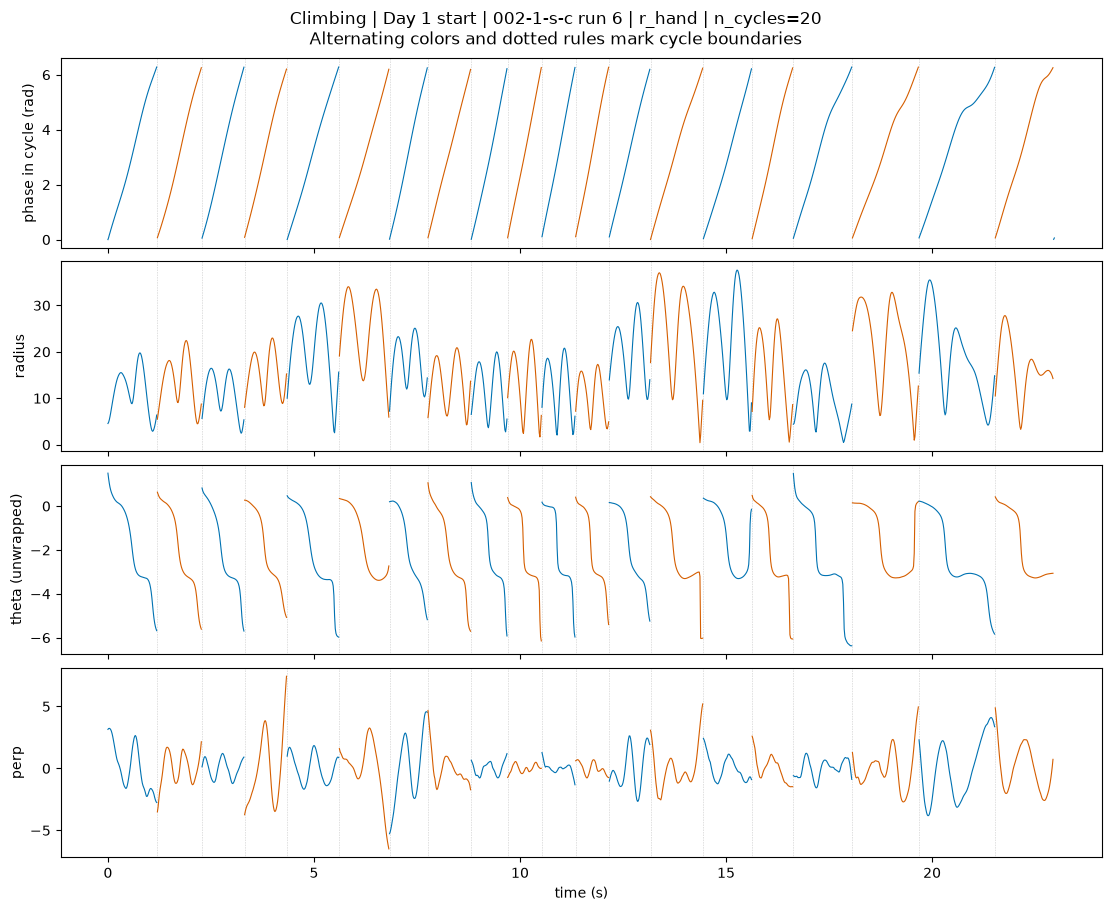

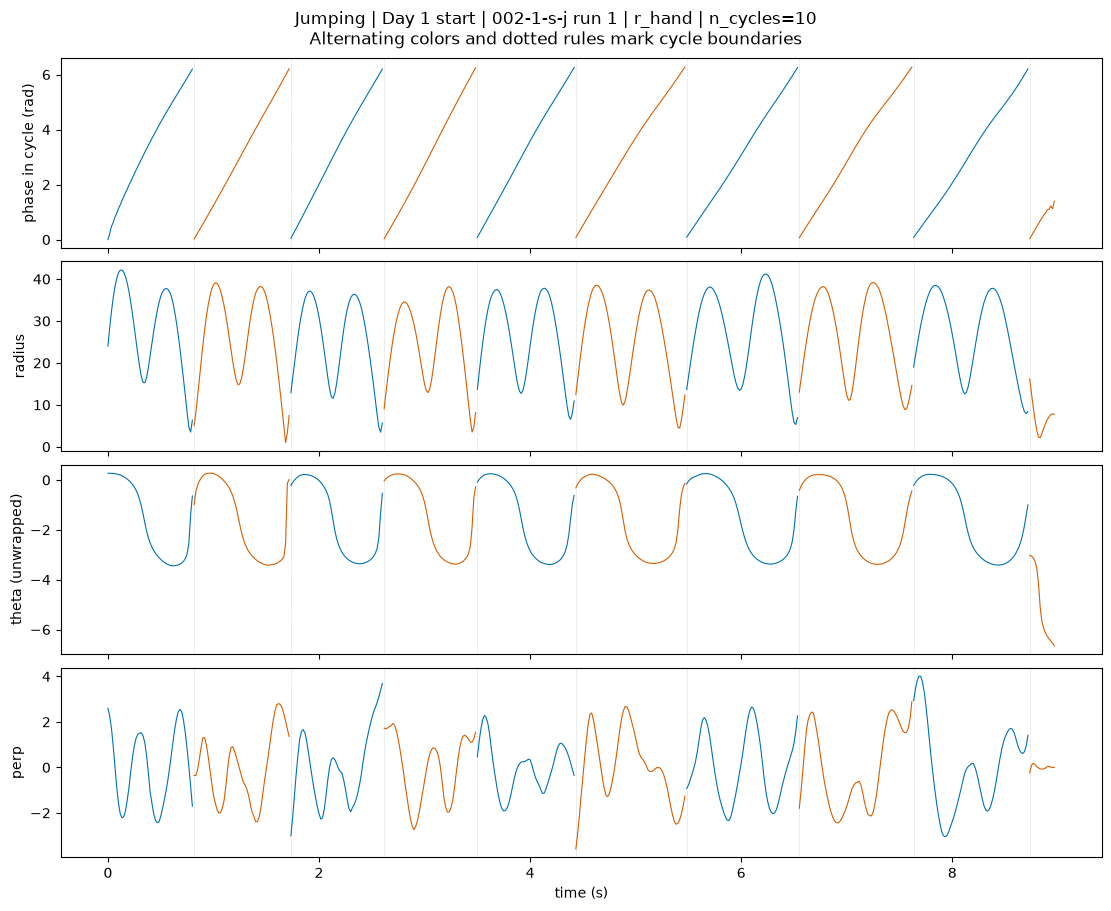

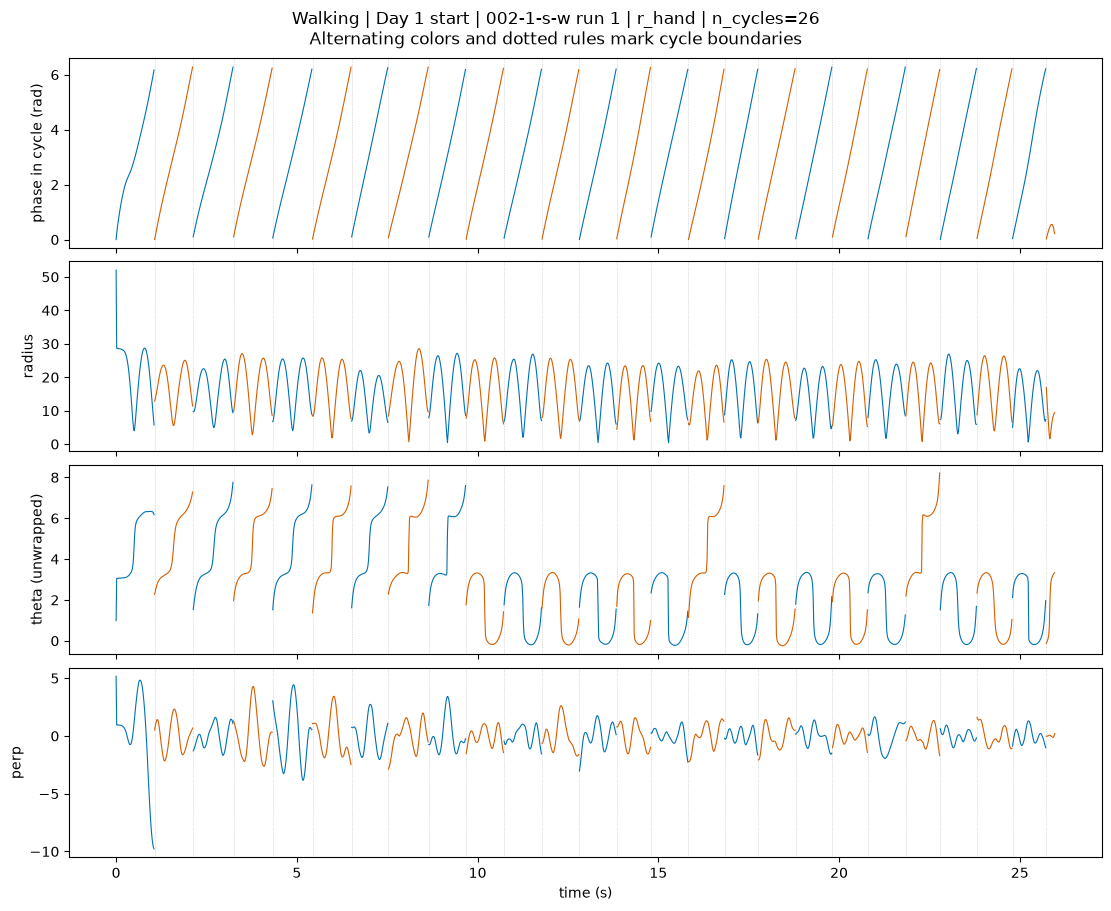

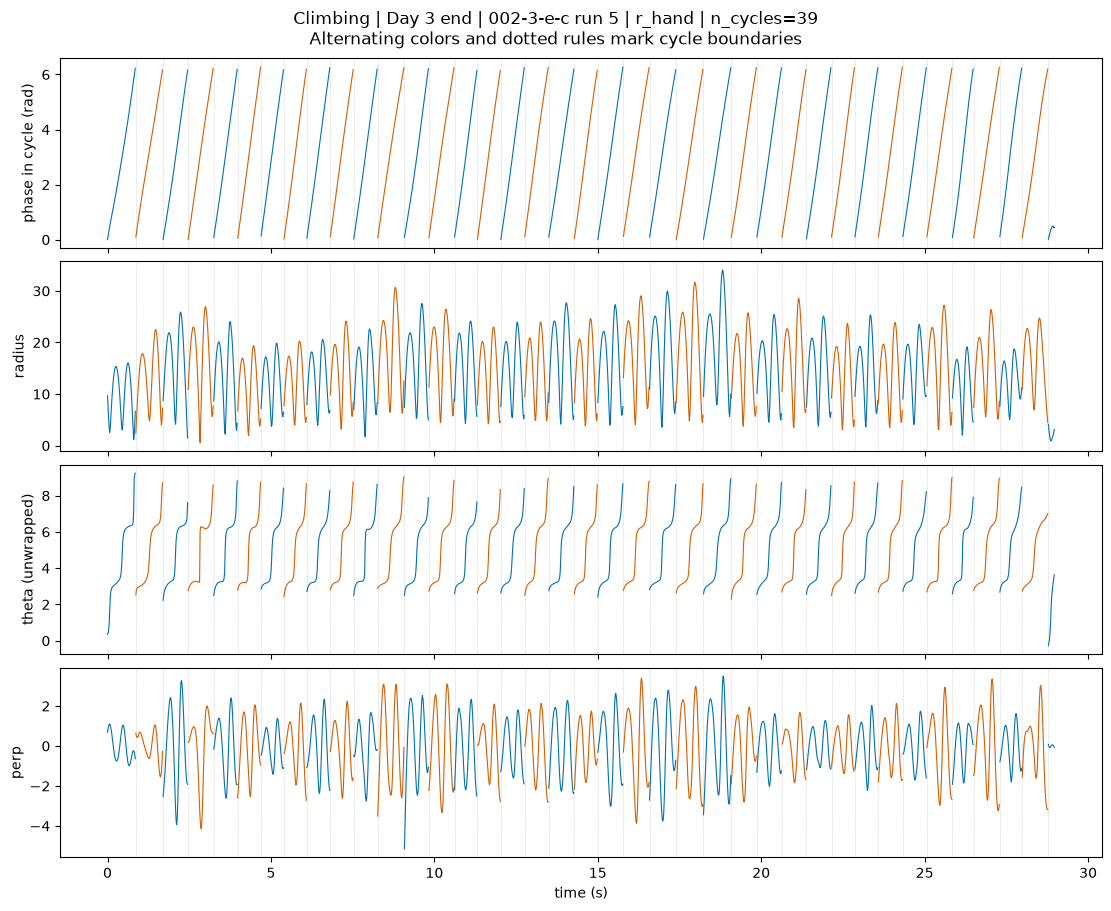

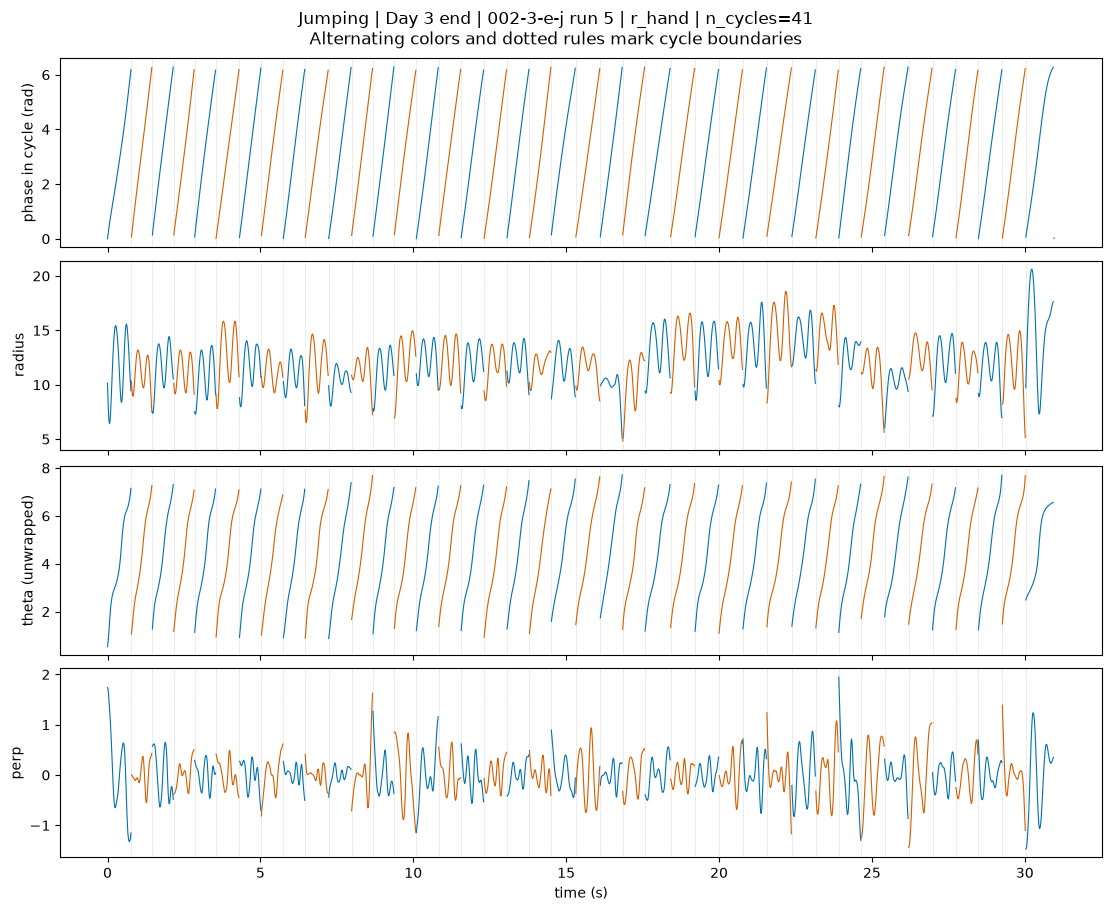

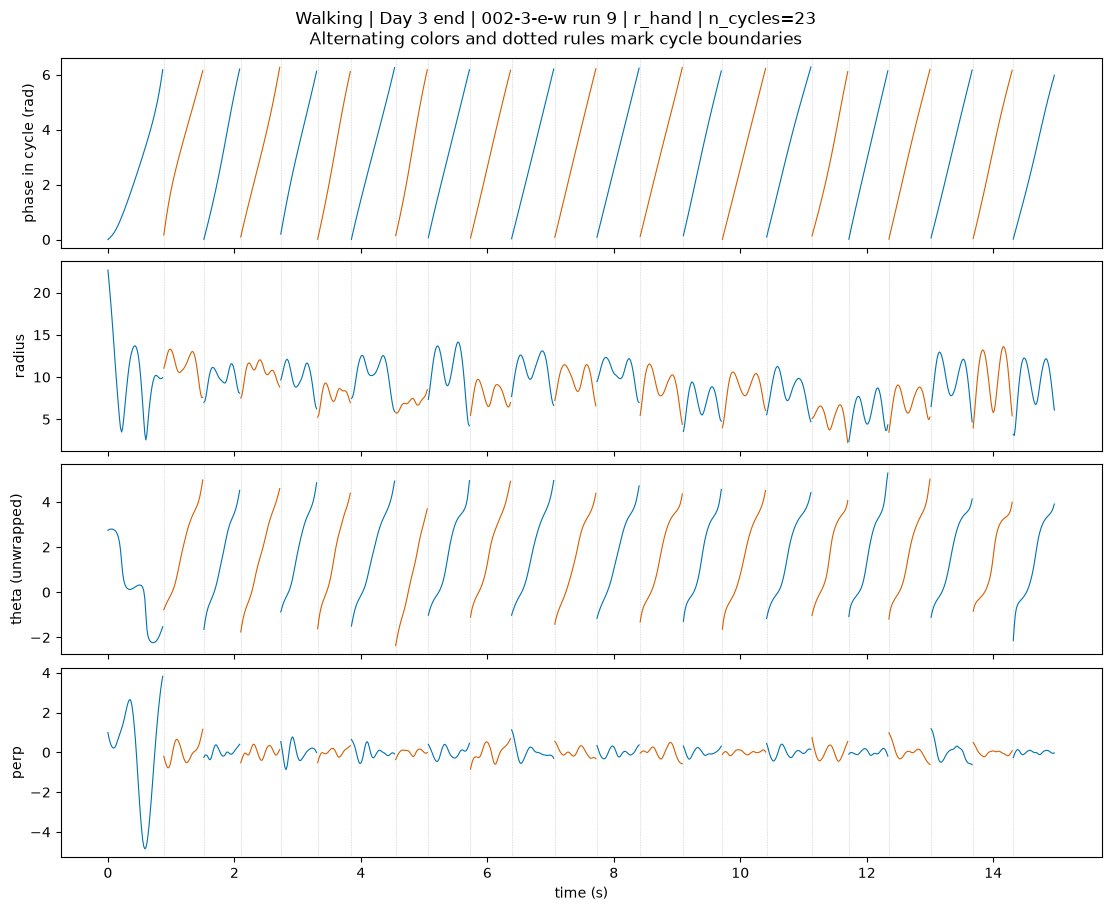

In [5]:
primary_keys = []
for (day, part, skill), group in runs.groupby(["day", "part", "skill"]):
    row = group.loc[group["run_duration_sec"].idxmax()]
    primary_keys.append((row.subject, int(row.day), row.part, row.skill, row.source_file, int(row.movement_run_id), "r_hand"))

for key in primary_keys:
    subject, day, part, skill, source_file, run_id, hand = key
    res = results.get(key)
    if res is None:
        print(f"SKIP {key}: no cached result (see anomalies table above)")
        continue
    samples, cycles = res["samples"], res["cycles"]
    fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
    P.plot_by_cycle(axes[0], samples, cycles, "phase_in_cycle")
    axes[0].set_ylabel("phase in cycle (rad)")
    P.plot_by_cycle(axes[1], samples, cycles, "radius")
    axes[1].set_ylabel("radius")
    P.plot_by_cycle(axes[2], samples, cycles, "theta")
    axes[2].set_ylabel("theta (unwrapped)")
    P.plot_by_cycle(axes[3], samples, cycles, "perp")
    axes[3].set_ylabel("perp")
    axes[3].set_xlabel("time (s)")
    fig.suptitle(f"{P.SKILL_LABELS[skill]} | {P.DAY_LABELS[day]} {P.PART_LABELS[part]} | "
                 f"{source_file} run {run_id} | {hand} | n_cycles={len(cycles)}\n"
                 "Alternating colors and dotted rules mark cycle boundaries")
    P.save_figure(fig, f"stage2_{skill}_day{day}{part}_{hand}_phase_radius_theta_perp")
    plt.show()


In [6]:
for key in primary_keys:
    subject, day, part, skill, source_file, run_id, hand = key
    res = results.get(key)
    if res is None:
        continue
    samples, cycles = res["samples"], res["cycles"]
    row = runs[(runs.source_file == source_file) & (runs.movement_run_id == run_id)].iloc[0]
    pos = L.load_position_file(row["path"], file_cache)
    seg = pos.iloc[int(row.run_start):int(row.run_end)]
    X, _ = _hand_xyz_relative_to_root(seg, hand)
    X_hat = reconstruct_phase_coordinates(samples, cycles)
    fitted = ~np.isnan(X_hat[:, 0])
    err = np.linalg.norm(X_hat[fitted] - X[fitted], axis=1)
    print(f"{skill:6s} day{day}{part} {hand}: max reconstruction error = {err.max():.2e} "
          f"({fitted.sum()}/{len(X)} samples fitted, {len(cycles)} cycles)")


climb  day1s r_hand: max reconstruction error = 4.78e-14 (1377/1379 samples fitted, 20 cycles)
jump   day1s r_hand: max reconstruction error = 4.77e-14 (539/539 samples fitted, 10 cycles)
walk   day1s r_hand: max reconstruction error = 3.28e-14 (1559/1559 samples fitted, 26 cycles)
climb  day3e r_hand: max reconstruction error = 3.92e-14 (1739/1739 samples fitted, 39 cycles)
jump   day3e r_hand: max reconstruction error = 2.30e-14 (1857/1859 samples fitted, 41 cycles)
walk   day3e r_hand: max reconstruction error = 1.95e-14 (899/899 samples fitted, 23 cycles)


## Summary

All 58 runs x 2 hands were fit with a single shared `F_RANGE=(0.5, 3.0)` Hz
Hilbert band (validated empirically above -- median cycle durations land
inside Noam's own skill-specific expected ranges for all three tasks, zero
phase-monotonicity warnings). Results and cycles are cached in
`cache/pca_results.pkl` for Stages 3-6. See `PROGRESS.md` for the anomaly
count and per-skill cycle-count/reconstruction-error summary.